In [1]:
import pickle
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.utils import shuffle

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import precision_score


def find_farthest_point(points):
    max_distance = 0
    farthest_point = None
    distance_list = []
    for i, point in enumerate(points):
        distances = [np.linalg.norm(point - other_point) for j, other_point in enumerate(points) if i != j]
        distance_list.append(sum(distances))
    min_index = pd.Series(distance_list).idxmax()
    return list(points[min_index])

def sort_by_distance(points):
    farthest_point = find_farthest_point(points)
    points = [list(p) for p in points]
    points.remove(farthest_point)
    sorted_points = [farthest_point]
    for i in range(len(points)):
        distances = [np.linalg.norm(np.array(sorted_points[i]) - np.array(other_point)) for other_point in points]
        min_index = pd.Series(distances).idxmin()
        sorted_points.append(points[min_index])
        points.remove(points[min_index])
    
    return sorted_points



def calc_normalized_data(data, target_columns, scaler_dict):
    for target in target_columns:
        mean, std = scaler_dict[target]
        normalized_scores = [(s-mean)/std for s in data[target]]
        data["normalized "+target] = normalized_scores
    return data

def sample_data(sub_dir_name, target_columns, scaler_dict, cache_dict, num_fold, root_dir, sample_num):
    data_dict = {}
    for sub_dir in sub_dir_name:
        if sub_dir == "original data":
            continue
        smiles2fitness_dict = {}
        all_smiles_list = []
        for i in range(1, num_fold+1):
            smiles_list = []
            fitness_list = []
            dir_name = os.path.join(root_dir, sub_dir+"_"+str(i))
            with open(os.path.join(dir_name, "population_explore.txt"), "r") as f:
                smiles_list += f.read().strip().split(" ")
            with open(os.path.join(dir_name, "fitness_explore.txt"), "r") as f:
                fitness_list += f.read().strip().split(" ")
            with open(os.path.join(dir_name, "population_local_search.txt"), "r") as f:
                smiles_list += f.read().strip().split(" ")
            with open(os.path.join(dir_name, "fitness_local_search.txt"), "r") as f:
                fitness_list += f.read().strip().split(" ")
            fitness_list = [float(x) for x in fitness_list]
            for smiles, fitness in zip(smiles_list, fitness_list):
                smiles2fitness_dict.update({smiles: fitness})            
            smiles_fitness_data = list(zip(smiles_list, fitness_list))
            unique_data = set_and_sort(smiles_fitness_data)
            all_smiles_list += list(zip(*unique_data[:sample_num]))[0]
        data = pd.DataFrame(columns=target_columns)
        all_smiles_list = list(set(all_smiles_list))
        for smiles in all_smiles_list:
            scores = cache_dict.get(smiles)
            if scores:
                if abs(scores[0]) != 10000:
                    scores = list(scores)
                    data = pd.concat([data, pd.DataFrame([[smiles]+scores], columns=["smiles"]+target_columns)], axis=0)
                else:
                    score = float("nan")
        data = calc_normalized_data(data, target_columns, scaler_dict)
        data["fitness"] = [smiles2fitness_dict.get(smiles) for smiles in data["smiles"]]
        data_dict.update({sub_dir: data.sort_values(by="fitness", ascending=False).reset_index(drop=True)})
#         data_dict.update({sub_dir: data})
    return data_dict

def set_and_sort(data):
    seen_names = set()
    unique_data = []
    for name, score in data:
        if name not in seen_names:
            seen_names.add(name)
            unique_data.append((name, score))
    unique_data.sort(key=lambda x: x[1], reverse=True)
    return unique_data

def binary_conversion(value, cutoff, objective):
    if objective == "maximize":
        if value >= cutoff:
            return 1
        else:
            return 0
    elif objective == "minimize":
        if value <= cutoff:
            return 1
        else:
            return 0
    
def statistics_cutoffs(data, cutoff_dict, target_objective, target_columns, num_fold):
    pass_cutoff_num = [0]*(len(target_columns)+1) # np.zeros(len(target_columns)+1)
    
    sub_num = np.zeros(len(data))
    for target in target_columns:
        subdata = data[[target]]
        binary_df = subdata[[target]].astype(float).applymap(lambda x: binary_conversion(x, cutoff_dict[target], target_objective[target]))
        sub_num += binary_df.values.reshape(1,-1)[0]
    for x in sub_num:
        pass_cutoff_num[int(x)] += 1
    return pass_cutoff_num    

def create_cutoff_plot(data_dict, sub_dir_name, target_columns, target_objective, cutoff_dict, num_fold, color_dict,
                       bar_width = 0.3):
    plt.figure(dpi=100)
    x = np.arange(len(target_columns)+1)
    for i, sub_dir in enumerate(sub_dir_name):
        data = data_dict[sub_dir]
        heights = statistics_cutoffs(data, cutoff_dict, target_objective, target_columns, num_fold)
        plt.bar(x+ bar_width*i, heights, width=bar_width, label=sub_dir, color=color_dict[sub_dir])

    plt.legend()
    plt.ylabel("Number of molecules")
    plt.xlabel("Number of objectives passing the thresholds")
    plt.xticks(x + bar_width*(len(sub_dir_name)-1)/2, [str(z) for z in range(0, len(target_columns)+1)])
#     plt.savefig(os.path.join(save_dir, "cutoff_objectives"+".svg"), format='svg')

def pass_all_cutoffs_index(data, target_columns, target_objective, cutoff_dict, cache_dict, predict_dict):
    reference_founds = []
    reference_founds_index = []
    for j, smiles in enumerate(data["smiles"]): # data_dict['janus_scaler']["smiles"]
        reference_values = cache_dict[smiles]
        ref_rev_sum = 0
        for i, target in enumerate(target_columns):
            ref_rev_sum += 1 - binary_conversion(reference_values[i], cutoff_dict[target], target_objective[target])
        ref_positive = int(not bool(ref_rev_sum))
        if ref_positive:
            reference_founds_index.append(j)
        reference_founds.append(ref_positive)
    return data.iloc[reference_founds_index]

def is_pass_all_cutoffs(data, target_columns, target_objective, cutoff_dict, cache_dict, predict_dict):
    reference_founds = []
    predict_founds = []
    for smiles in data["smiles"]: # data_dict['janus_scaler']["smiles"]
        reference_values = cache_dict[smiles]
        predict_values = predict_dict[smiles]
        ref_rev_sum = 0
        pred_rev_sum = 0
        for i, target in enumerate(target_columns):
            ref_rev_sum += 1 - binary_conversion(reference_values[i], cutoff_dict[target], target_objective[target])
            pred_rev_sum += 1 - binary_conversion(predict_values[i], cutoff_dict[target], target_objective[target])
        ref_positive = int(not bool(ref_rev_sum))
        pred_positive = int(not bool(pred_rev_sum))
        reference_founds.append(ref_positive)
        predict_founds.append(pred_positive)
    return reference_founds, predict_founds

def create_confusion_matrix_plot(data_dict, method_list, target_columns, target_objective, cutoff_dict, cache_dict, predict_dict):
    for method in method_list:        
        reference_founds, predict_founds = is_pass_all_cutoffs(data_dict[method], target_columns, 
                                                               target_objective, cutoff_dict, cache_dict, predict_dict)
        print(method)
        print(reference_founds)
        print(predict_founds)
        print("precision:", precision_score(reference_founds, predict_founds))
        ConfusionMatrixDisplay.from_predictions(reference_founds, predict_founds, normalize="all")
    return
    

def compute_precision(data_dict, method_list, target_columns, target_objective, cutoff_dict, cache_dict, predict_dict):
    for method in method_list:
        if method == "original data":
            continue
        reference_founds, predict_founds = is_pass_all_cutoffs(data_dict[method], target_columns, 
                                                               target_objective, cutoff_dict, cache_dict, predict_dict)
        print(method)
        print("precision:", precision_score(reference_founds, predict_founds))
    return

def compute_hit_rate(benchmark_dict, method_list, target_cutoff, target_objective, top_list=[10,50,100]):
    for top_num in top_list:
        for method in method_list:
            sub_data = benchmark_dict[method][:top_num]
            for target, objective in target_objective.items():
                cutoff = target_cutoff[target]
                if objective == "maximize":
                    sub_data = sub_data[sub_data[target] >= cutoff]
                elif objective == "minimize":
                    sub_data = sub_data[sub_data[target] <= cutoff]
            found = len(sub_data)
            print(f"{method}, top-{top_num} hit rate: {found/top_num*100}%")

### Organic Emitter

In [15]:
# num_samples_in_each_fold = 5
data_set = "organic_emitter" # _125_cutoff
data_path = "./Tartarus/datasets/gdb13.csv"
root_dir = "./RESULTS/{}".format(data_set)
cache_dict_path = "./RESULTS/{}/cal_dict.pkl".format(data_set)
predict_dict_path = "./RESULTS/{}/predict_dict.pkl".format(data_set)
with open(cache_dict_path, "rb") as f:
    cache_dict = pickle.load(f)
with open(predict_dict_path, "rb") as g:
    predict_dict = pickle.load(g)

""" The singlet-triplet value shoulb time minus one !!! """
for smiles, target_values in predict_dict.items():
    stv, osv, mov = target_values
    predict_dict[smiles] = (-stv, osv, mov)
    
sub_dir_name = ["janus_utopian", "janus_hybrid","janus_uncertainty"]
target_columns = ["singlet-triplet value", "oscillator strength", "abs_diff_vee"]
scaler_dict = {"singlet-triplet value": (1.003, 0.396), "oscillator strength": (0.086, 0.149), "abs_diff_vee": (2.688, 1.038),}
# top-10% cutoff
# cutoff_dict = {"singlet-triplet value":-0.4886, "oscillator strength":0.373, "multi-objective value": -0.679}
# top-12.5% cutoff
# cutoff_dict = {"singlet-triplet value":-0.5302, "oscillator strength":0.1983, "abs_diff_vee": 1.5262}
# top-15% cutoff
cutoff_dict = {"singlet-triplet value":-0.57068, "oscillator strength":0.1706886, "abs_diff_vee": 1.615238}

target_objective = {"singlet-triplet value":"maximize", 
                    "oscillator strength":"maximize", 
                    "abs_diff_vee":"minimize"}

color_dict = {"original data": "black", "janus_hybrid":"red", "janus_uncertainty":"green", "janus_utopian":"blue"}
num_fold = 15
normalized_cutoff_dict = { key: (value-scaler_dict[key][0])/scaler_dict[key][1] for key, value in cutoff_dict.items() }


data = pd.read_csv(data_path)
data["singlet-triplet value"] = (-1) * data["singlet-triplet value"]
data = shuffle(calc_normalized_data(data, target_columns, scaler_dict),random_state=12)[:1000]
data_dict = sample_data(sub_dir_name, target_columns, scaler_dict, cache_dict, num_fold, root_dir,sample_num=-1)
data_dict.update({"original data": data})
compute_hit_rate(data_dict, sub_dir_name, cutoff_dict, target_objective, top_list=[10,50,100])
# for creating a responsive plot

janus_utopian, top-10 hit rate: 20.0%
janus_hybrid, top-10 hit rate: 0.0%
janus_uncertainty, top-10 hit rate: 80.0%
janus_utopian, top-50 hit rate: 28.000000000000004%
janus_hybrid, top-50 hit rate: 0.0%
janus_uncertainty, top-50 hit rate: 44.0%
janus_utopian, top-100 hit rate: 15.0%
janus_hybrid, top-100 hit rate: 0.0%
janus_uncertainty, top-100 hit rate: 22.0%


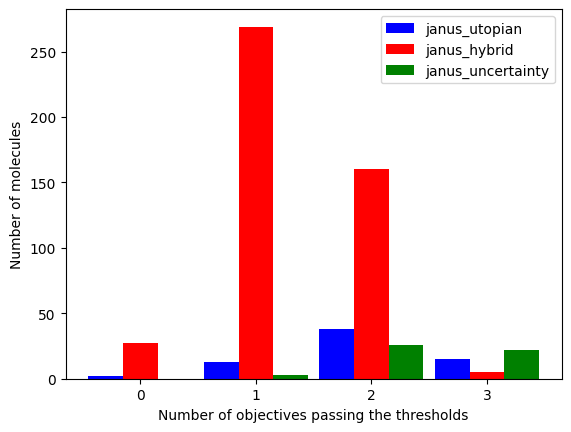

In [16]:
create_cutoff_plot(data_dict, sub_dir_name, target_columns, target_objective, cutoff_dict, num_fold, color_dict)

### Reaction substrate design (reactivity)

In [5]:
num_samples_in_each_fold = 10

data_set = "reactivity" # _125_cutoff
data_path = "./Tartarus/datasets/reactivity.csv"
root_dir = "./RESULTS/{}".format(data_set)
cache_dict_path = "./RESULTS/{}/cal_dict.pkl".format(data_set)
predict_dict_path = "./RESULTS/{}/predict_dict.pkl".format(data_set)
with open(cache_dict_path, "rb") as f:
    cache_dict = pickle.load(f)
with open(predict_dict_path, "rb") as g:
    predict_dict = pickle.load(g)
    
sub_dir_name = ["janus_utopian","janus_hybrid", "janus_uncertainty"]
target_columns = ["Ea", "Er",]
scaler_dict = {"Ea": (84.104, 3.076), "Er": (-0.749, 4.507),}
# top-12.5%
# cutoff_dict = {"Ea": 87.3226545, "Er": -6.41327,}
# top-15%
cutoff_dict = {"Ea": 86.96834, "Er": -5.46226,} 
target_objective = {"Ea":"maximize", 
                    "Er":"minimize",}
color_dict = {"original data": "black", "janus_hybrid":"red", "janus_uncertainty":"green", "janus_utopian":"blue"}
num_fold = 15
normalized_cutoff_dict = { key: (value-scaler_dict[key][0])/scaler_dict[key][1] for key, value in cutoff_dict.items() }


data = pd.read_csv(data_path)
data = shuffle(calc_normalized_data(data, target_columns, scaler_dict),random_state=12)[:1000]
data_dict = sample_data(sub_dir_name, target_columns, scaler_dict, cache_dict, num_fold, root_dir,sample_num=-1)
data_dict.update({"original data": data})
compute_hit_rate(data_dict, sub_dir_name, cutoff_dict, target_objective, top_list=[10,50,100])

janus_utopian, top-10 hit rate: 10.0%
janus_hybrid, top-10 hit rate: 40.0%
janus_uncertainty, top-10 hit rate: 40.0%
janus_utopian, top-50 hit rate: 12.0%
janus_hybrid, top-50 hit rate: 16.0%
janus_uncertainty, top-50 hit rate: 22.0%
janus_utopian, top-100 hit rate: 9.0%
janus_hybrid, top-100 hit rate: 11.0%
janus_uncertainty, top-100 hit rate: 23.0%


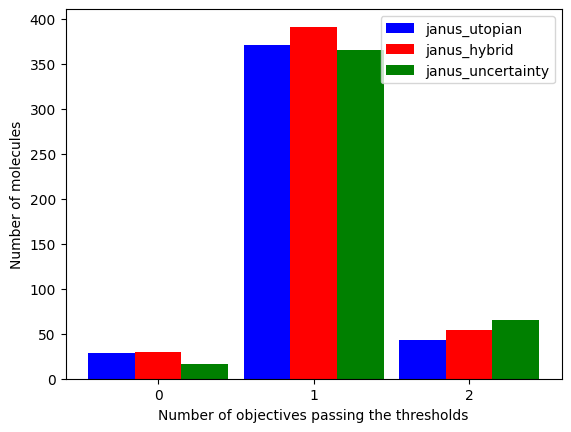

In [6]:
create_cutoff_plot(data_dict, sub_dir_name, target_columns, target_objective, cutoff_dict, num_fold, color_dict)

In [7]:
import umap
from rdkit import Chem, DataStructs
from rdkit.Chem.rdchem import Mol
from rdkit.Chem.MolStandardize.rdMolStandardize import LargestFragmentChooser
import seaborn as sns

def _compute_single_ecfp_descriptor(smiles: str):
    try:
        mol = Chem.MolFromSmiles(smiles)
    except Exception as E:
        return None

    if mol:
        fp = Chem.AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
        return np.array(fp)
    
    return None

def compute_ecfp_descriptors(smiles_list):
    """ Computes ecfp descriptors """
    
    keep_idx = []
    descriptors = []
    for i, smiles in enumerate(smiles_list):
        ecfp = _compute_single_ecfp_descriptor(smiles)
        if ecfp is not None:
            keep_idx.append(i)
            descriptors.append(ecfp)

    return np.vstack(descriptors), keep_idx

def _compute_single_ecfp_descriptor(smiles: str):
    try:
        mol = Chem.MolFromSmiles(smiles)
    except Exception as E:
        return None

    if mol:
        fp = Chem.AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
        return np.array(fp)
    
    return None


/home/lungyi/anaconda3/envs/uncmoo2/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [17]:
smaple_num = 100

# col_names = ["smiles", 'Ea', 'Er']
col_names = ["smiles", 'singlet-triplet value','oscillator strength','abs_diff_vee']
data_dict["original data"] = pd.read_csv(data_path)[col_names]
all_data = pd.DataFrame()
for sub_dir in ["original data", 'janus_hybrid', 'janus_utopian', 'janus_uncertainty']:
    sub_data = data_dict[sub_dir]
    sub_data["label"] = sub_dir
    if sub_dir != "original data":
        sub_data = sub_data[:smaple_num]
    all_data = pd.concat([all_data, sub_data], axis = 0)

ecfp_descriptors, keep_idx = compute_ecfp_descriptors(all_data["smiles"])
all_data = all_data.iloc[keep_idx]

In [18]:
umap_model = umap.UMAP(metric = "jaccard",
                      n_neighbors = 25,
                      n_components = 2,
                      low_memory = False,
                      min_dist = 0.001)
X_umap = umap_model.fit_transform(ecfp_descriptors)
all_data["UMAP_0"], all_data["UMAP_1"] = X_umap[:,0], X_umap[:,1]
all_data.to_csv("figures/umap/organic_emitter_umap.csv")

/home/lungyi/anaconda3/envs/uncmoo2/lib/python3.8/site-packages/umap/umap_.py:1879: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(


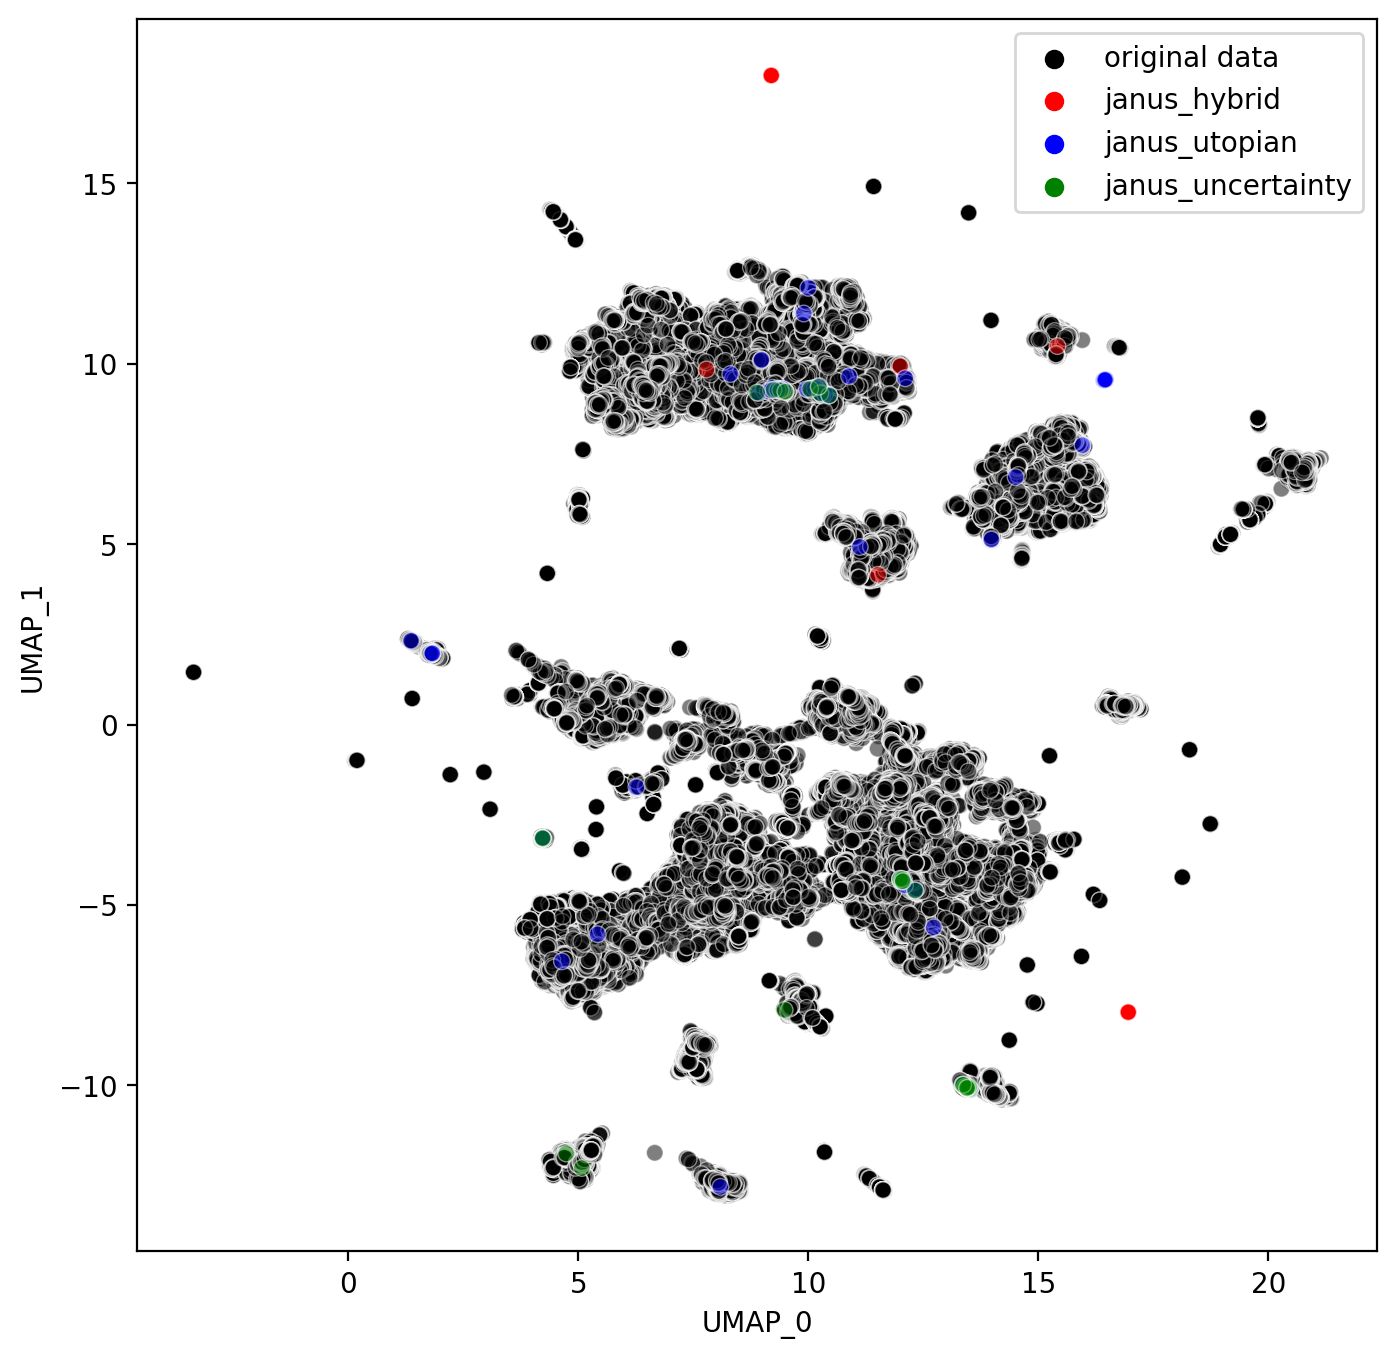

In [19]:
palette = sns.color_palette(["black", "red", "blue", "green", ])

plt.figure(figsize=(8,8), dpi=200)
sns.scatterplot(data=all_data,
                x="UMAP_0",
                y="UMAP_1",
                hue="label",
                alpha=0.5,
                palette=palette)
plt.legend()
plt.tight_layout()
plt.savefig("figures/umap/organic_emitter.png")
plt.show()